<a href="https://colab.research.google.com/github/YakoYakoko/Estudios/blob/main/Copia_de_5_Ejemplos_de_aplicaci%C3%B3n_de_la_regresi%C3%B3n_lineal_simple_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

En esta sección revisaremos algunos casos en los que buscaremos aplicar la regresión lineal simple.

# Ejemplo 1

### Agua embotellada

In [ ]:
agua <- read.csv("bottledwater.csv")
head(agua)

temperature_max,bottled_water_sales
78,23
79,22
80,24
80,22
82,24
83,26


**Suponemos** que existe una relación lineal entre la temperatura y la cantidad de botellas de agua vendidas:

$$B = \alpha_0+\alpha_1 T+\epsilon$$

### Gráfica de dispersión

Revisamos los datos a partir de una gráfica de dispersión buscando evidencia de la validez del modelo de regreión lineal simple.

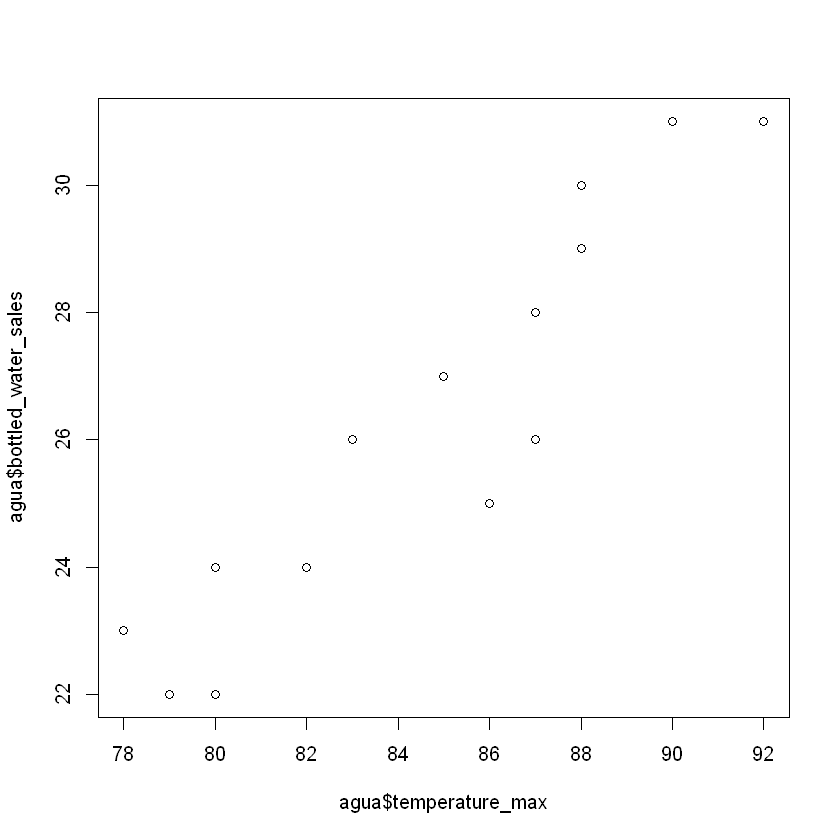

In [ ]:
 plot(agua$temperature_max, agua$bottled_water_sales)

La gráfica no muestra evidencia en contra de la aplicación del modelo.

### Coefciiente de correlación

Otra evidencia de la validez del modelo lineal sobre el conjinto de datos es el valor del coeficiente de correlación.

In [ ]:
cor(agua$temperature_max, agua$bottled_water_sales)

[1] 0.9324743

Este coeficiente adquiere valores cercanos a cero cuando las variables predictora y de repsuesta son **independientes**, mientras que su valor absoluto es cercano a una unidad si ambas variables están **relacionadas linealmente**.

### Estimación de los parámetros

Estimamos los parámetros del modelo lineal por medio de las fórmulas,

In [ ]:
x <- agua$temperature_max
y <- agua$bottled_water_sales

a1 <- cov(x,y)/var(x)
a0 <- mean(y)-mean(x)*a1

In [ ]:
print(a0)
print(a1)

[1] -30.6972
[1] 0.6732158


Utilizamos $\texttt{R}$ para realizar el ajuste.

In [ ]:
# ajustamos el modelo (estimamos los coeficientes) y evaluamos la calidad del ajuste
r <- lm(bottled_water_sales~temperature_max, data = agua)
summary(r)


Call:
lm(formula = bottled_water_sales ~ temperature_max, data = agua)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.1994 -0.5016  0.2908  0.8350  1.4542 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)     -30.69720    6.38033  -4.811 0.000425 ***
temperature_max   0.67322    0.07529   8.942 1.18e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 1.184 on 12 degrees of freedom
Multiple R-squared:  0.8695,	Adjusted R-squared:  0.8586 
F-statistic: 79.96 on 1 and 12 DF,  p-value: 1.182e-06


El modelo estimado es

$$B = -30.697+0.6732\;T$$

El cual indica que por cada grado que aumenta la temperatura (en escala Fahrenheit) se espera un aumento $0.6732$ en el total de botellas de agua vendidas.

**¿Utilizarían el modelo para predecir el total de botellas de agua que se venderán?**
TIene un buen valor r cuadrada. Que nos indica que el modelo puede explicar un 86.9% de la varianza, lo cual es bueno para un modelo de regresión lineal

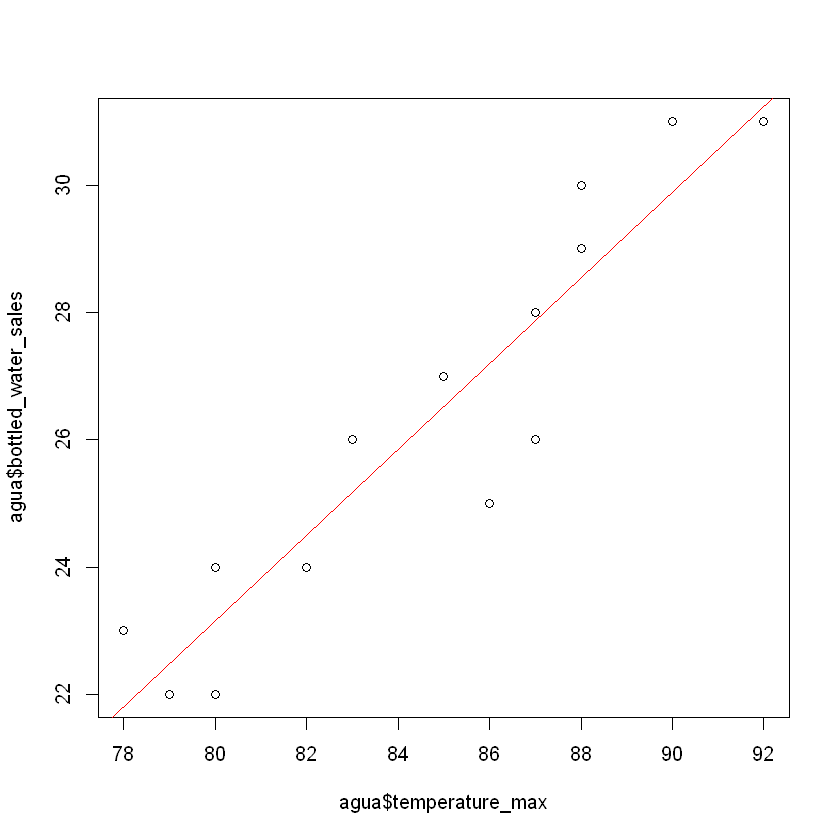

In [ ]:
# mostramos evidencia de la validez del modelo
plot(agua$temperature_max, agua$bottled_water_sales)
abline(r, col="red")

# Ejemplo 2

### Grillos


In [ ]:
grillos <- read.csv("grillos.csv")
head(grillos)

Warning message in file(file, "rt"):
“cannot open file 'grillos.csv': No such file or directory”


ERROR: Error in file(file, "rt"): cannot open the connection


Revisamos los datos

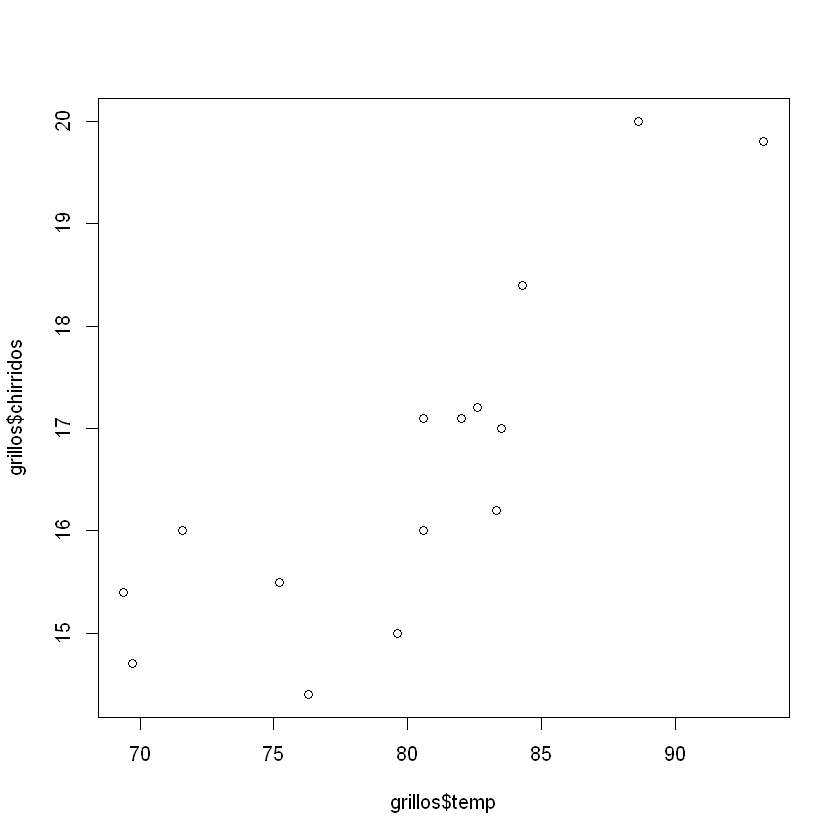

In [ ]:
plot(grillos$temp, grillos$chirridos)

In [ ]:
cor(grillos$chirridos, grillos$temp)

[1] 0.8351438

**Suponemos** que los datos pueden ser explicados por un modelo lineal

$$C = \alpha_0 + \alpha_1 T+\epsilon$$

In [ ]:
# ajustamos el modelo
r <- lm(chirridos ~temp, data = grillos)
summary(r)


Call:
lm(formula = chirridos ~ temp, data = grillos)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.56009 -0.57930  0.03129  0.59020  1.53259 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.30914    3.10858  -0.099 0.922300    
temp         0.21192    0.03871   5.475 0.000107 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.9715 on 13 degrees of freedom
Multiple R-squared:  0.6975,	Adjusted R-squared:  0.6742 
F-statistic: 29.97 on 1 and 13 DF,  p-value: 0.0001067


El modelo estimado es

$$C = -0.30914+0.2119\;T$$

El cual indica que, para esa especie de grillo, por cada grado que aumenta la temperatura (en escala Fahrenheit) se espera un aumento en de una 0.2119 en el total de chirridos por minuto.

El modelo explica un $70\%$ de la varianza de la variable de respuesta.

**¿Utilizarían el modelo para predecir el total de chirridos por minuto a partir de la temperatura?**

TIene una buena correlación entre datos y buen indicador r cuadrada. Obviamente por la naturaleza del problema tiene limitaciones este modelo. Como poner temperaturas bajas, probablemente prediga valores negativos o cercanos a 0 cuando un grillo en estas situaciones probablemente este muerto.

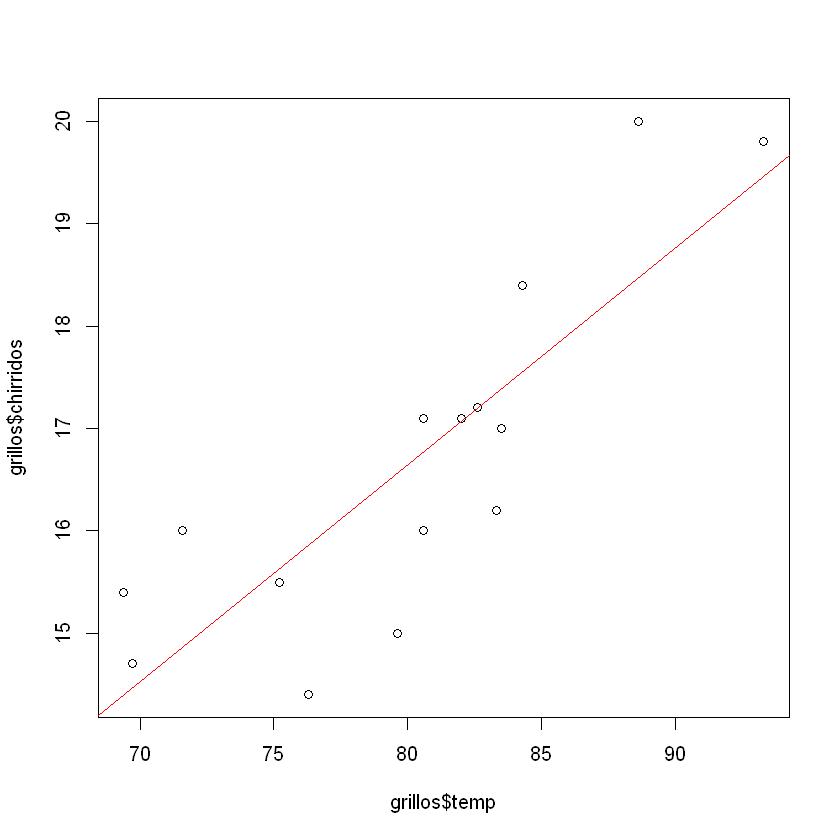

In [ ]:
plot(grillos$temp, grillos$chirridos)
abline(r, col="red")

# Ejemplo 3

### Examen

In [ ]:
examen <- read.csv("exam_dat.csv")
head(examen)

marks,times
49,2860
49,2063
70,2013
55,2000
52,1420
55,1934


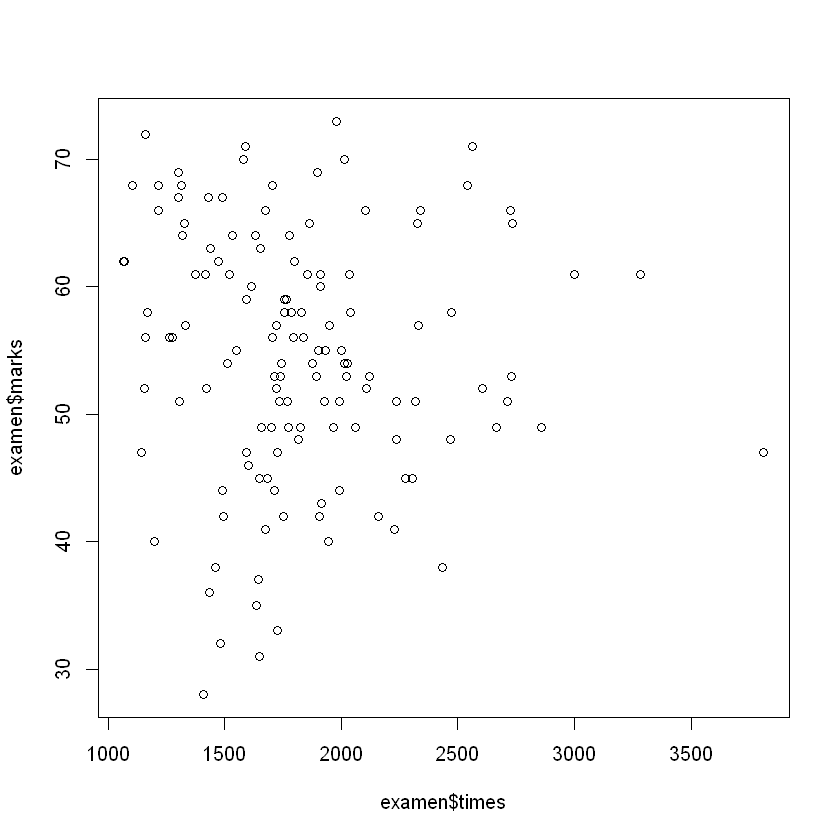

In [ ]:
plot(examen$times, examen$marks)

In [ ]:
cor(examen$marks, examen$times)

[1] -0.05713813

**¿El modelo lineal será válido?**

$$C = \alpha_0+\alpha_1T+\epsilon$$

In [ ]:
r <- lm(marks ~ times, data=examen)
summary(r)


Call:
lm(formula = marks ~ times, data = examen)

Residuals:
    Min      1Q  Median      3Q     Max 
-27.029  -5.720   0.352   7.341  18.660 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 56.733267   3.457018  16.411   <2e-16 ***
times       -0.001208   0.001837  -0.658    0.512    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 9.835 on 132 degrees of freedom
Multiple R-squared:  0.003265,	Adjusted R-squared:  -0.004286 
F-statistic: 0.4324 on 1 and 132 DF,  p-value: 0.512


**¿Utilizarían el modelo para predecir la calificación a partir del tiempo que el estudiante dedicó al examen?**

\begin{align}
    H_0 :  \widehat{\alpha_1} = 0\\
    H_A :  \widehat{\alpha_1} \neq 0\\
\end{align}

No. La naturaleza de estos datos parece ser atipica. O que alguien no puede subir su calificación en un exámen por más veces que lo presente, incluso algunas veces parece que empeora su resultado. A lo mejor es como fue medida la prueba, por más que lo presenten sin estudiar estos no pueden avanzar (o a lo mejor no se les da el tema) por eso la gráfica de dispersión tan rara. esto se refleja en el valor r cuadrado que es muy pequeño parqa una regresión lineal.

# Ejemplo 4

### Pesos del cuerpo y del cerebro

https://stat.ethz.ch/R-manual/R-devel/library/MASS/html/Animals.html

In [ ]:
peso <- read.csv("brain_weight.csv")
head(peso)

brain_weight,body_weight
3.385,44.5
0.480,15.5
1.350,8.1
465.000,423.0
36.330,119.5
27.660,115.0


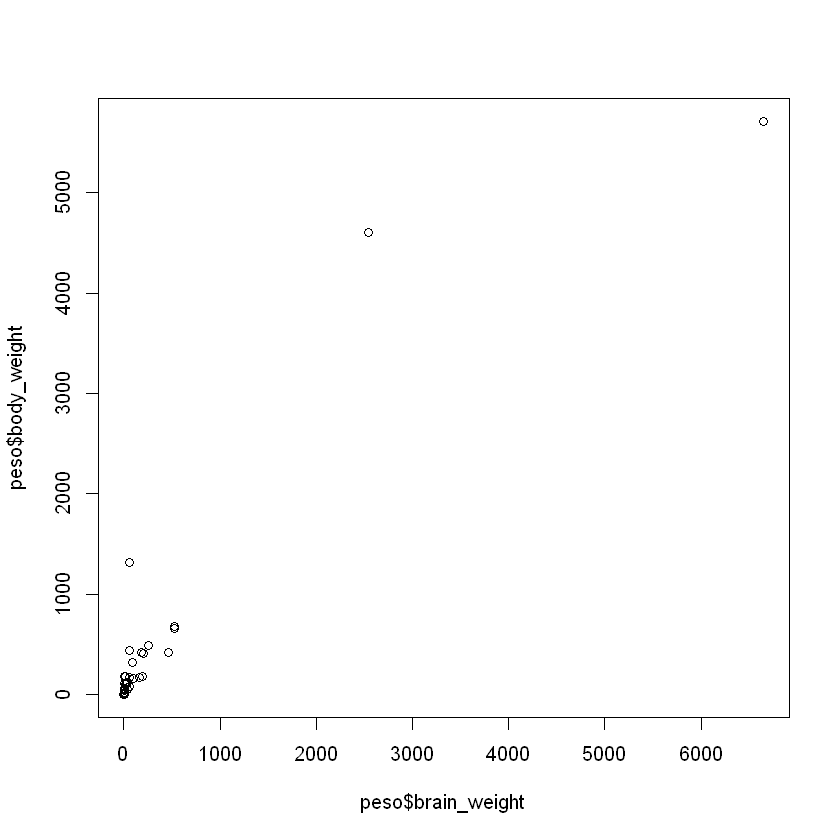

In [ ]:
plot(peso$brain_weight, peso$body_weight)

Observa que el conjunto tiene datos atípicos:

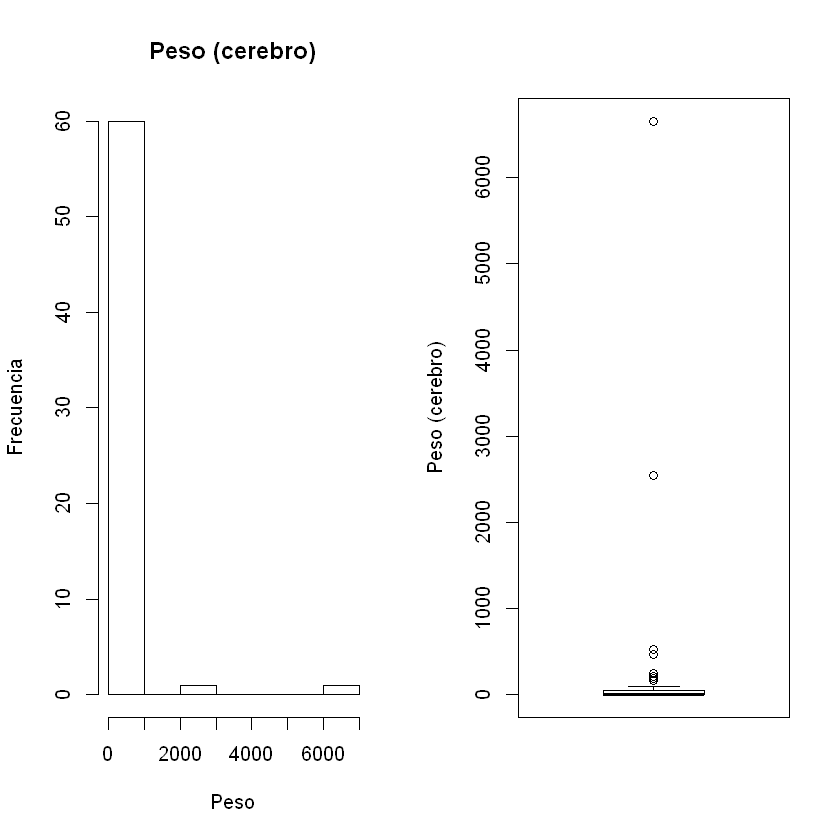

In [ ]:
par(mfrow=c(1,2))
hist(peso$brain_weight, xlab = "Peso", ylab = "Frecuencia", main = "Peso (cerebro)")
boxplot(peso$brain_weight, ylab = "Peso (cerebro)")

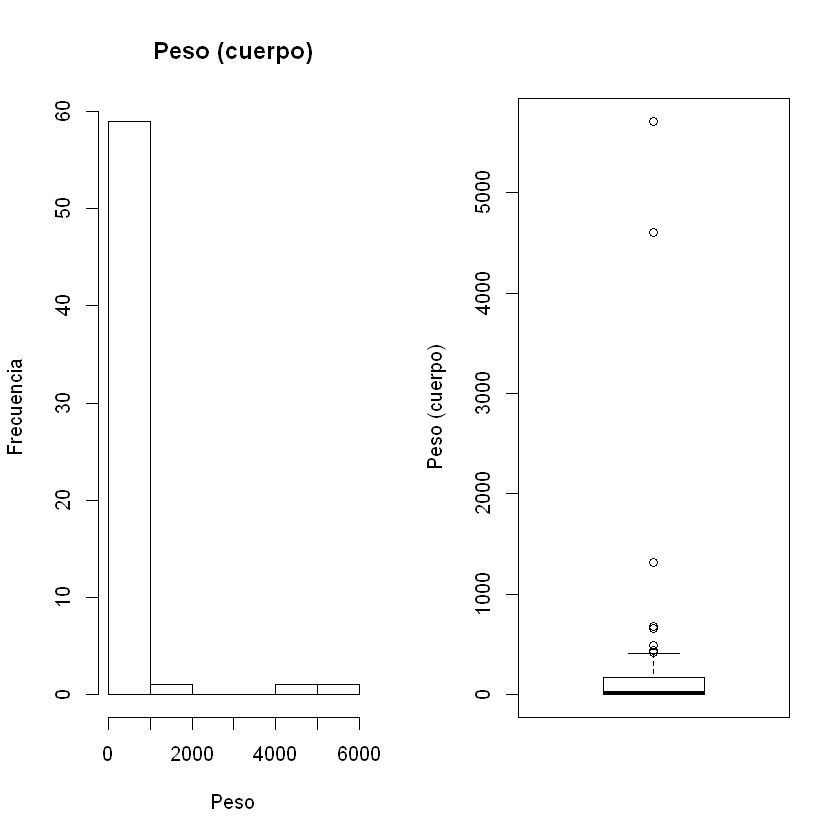

In [ ]:
par(mfrow=c(1,2))
hist(peso$body_weight, xlab = "Peso", ylab = "Frecuencia", main = "Peso (cuerpo)")
boxplot(peso$body_weight, ylab = "Peso (cuerpo)")

In [ ]:
cor(peso$brain_weight, peso$body_weight)

[1] 0.9341638

In [ ]:
r <- lm(body_weight ~ brain_weight, data=peso)
summary(r)


Call:
lm(formula = body_weight ~ brain_weight, data = peso)

Residuals:
    Min      1Q  Median      3Q     Max 
-810.07  -88.52  -79.64  -13.02 2050.33 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  91.00440   43.55258    2.09   0.0409 *  
brain_weight  0.96650    0.04766   20.28   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 334.7 on 60 degrees of freedom
Multiple R-squared:  0.8727,	Adjusted R-squared:  0.8705 
F-statistic: 411.2 on 1 and 60 DF,  p-value: < 2.2e-16


**¿Utilizarían el modelo para predecir el peso del cuerpo de un mamífero en función del peso del cerebro?**
Parece tener algunos valores atipicos pero tiene buen intercepto y buen r cuadrado, la gráfica parece un poco complicada pero con un poco de tratamiento de datos puede ser mejor.

Eliminamos algunas observaciones atípicas



In [ ]:
sort(peso$brain_weight)

[1]    0.005    0.010    0.023    0.023    0.048    0.060    0.075    0.101
 [9]    0.104    0.120    0.122    0.200    0.280    0.425    0.480    0.550
[17]    0.750    0.785    0.900    0.920    1.000    1.040    1.350    1.400
[25]    1.410    1.620    1.700    2.000    2.500    3.000    3.300    3.385
[33]    3.500    3.500    3.600    4.050    4.190    4.235    4.288    6.800
[41]   10.000   10.550   14.830   27.660   35.000   36.330   52.160   55.500
[49]   60.000   62.000   85.000  100.000  160.000  187.100  192.000  207.000
[57]  250.000  465.000  521.000  529.000 2547.000 6654.000

In [ ]:
peso <- peso[peso$brain_weight < 1000, ]
peso <- peso[peso$body_weight < 1000, ]

In [ ]:
cor(peso$brain_weight, peso$body_weight)

[1] 0.8884084

In [ ]:
r <- lm(body_weight ~ brain_weight, data=peso)
summary(r)


Call:
lm(formula = body_weight ~ brain_weight, data = peso)

Residuals:
    Min      1Q  Median      3Q     Max 
-184.81  -34.52  -27.16    0.67  339.35 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  36.57231   10.95089    3.34  0.00148 ** 
brain_weight  1.22847    0.08408   14.61  < 2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 77.15 on 57 degrees of freedom
Multiple R-squared:  0.7893,	Adjusted R-squared:  0.7856 
F-statistic: 213.5 on 1 and 57 DF,  p-value: < 2.2e-16


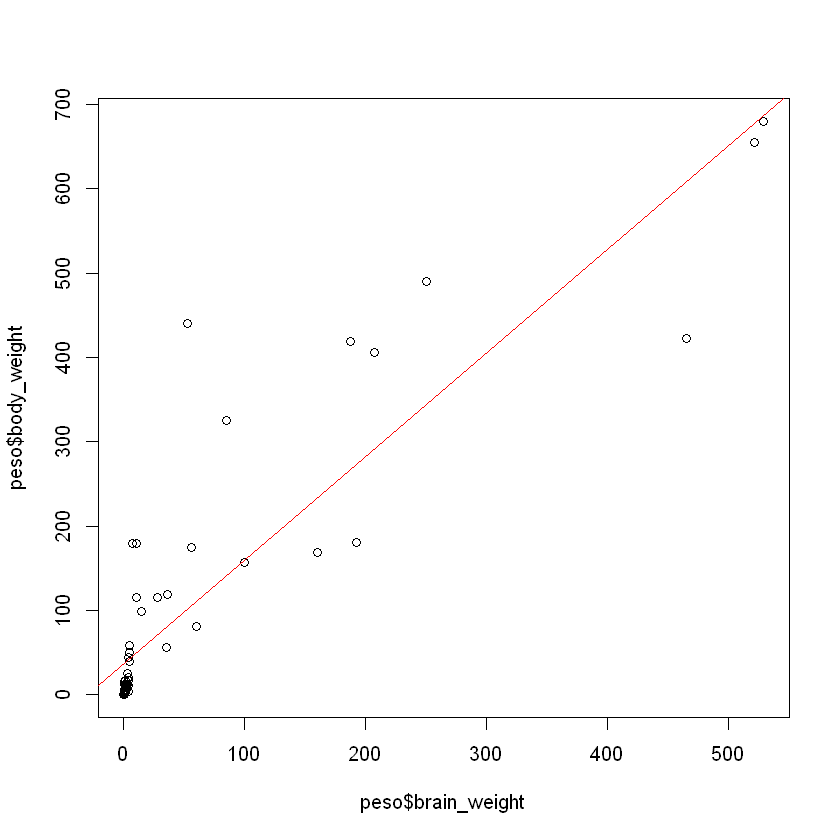

In [ ]:
plot(peso$brain_weight, peso$body_weight)
abline(r, col="red")

<font color="red">Actividad</font>

Analiza el conjunto de datos $\texttt{cars}$ (incluido en $\texttt{R}$ por lo que no es necesario abrir un archivo de datos).

1. Construye gráficas para revisar la distribución de las variables:
    1. $\texttt{speed}$: velocidad de un automóvil (millas/h)
    2. $\texttt{dist}$: distancia de frenado (pies)
2. Busca evidencia de una posible relación lineal entre las variables construyendo una gráfica de dispersión.
3. Evalúa el coeficiente de correlación entre la velocidad y la distancia de frenado.
4. Ajusta un modelo lineal para explicar la relación entre la velocidad de un automóvil e interpreta los resultados.




Heads

In [2]:
coches <- cars
head(coches)

,speed,dist
,<dbl>,<dbl>
1,4,2
2,4,10
3,7,4
4,7,22
5,8,16
6,9,10


Gráfica de dispersión

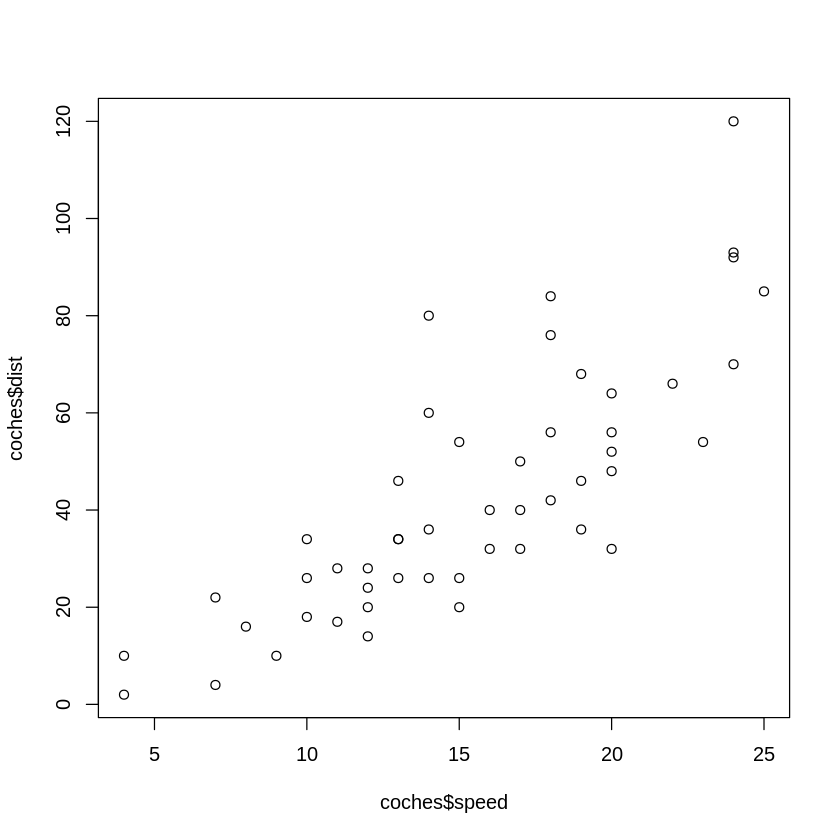

In [3]:
plot(coches$speed, coches$dist)

Datos atípicos / parece que todo bien.

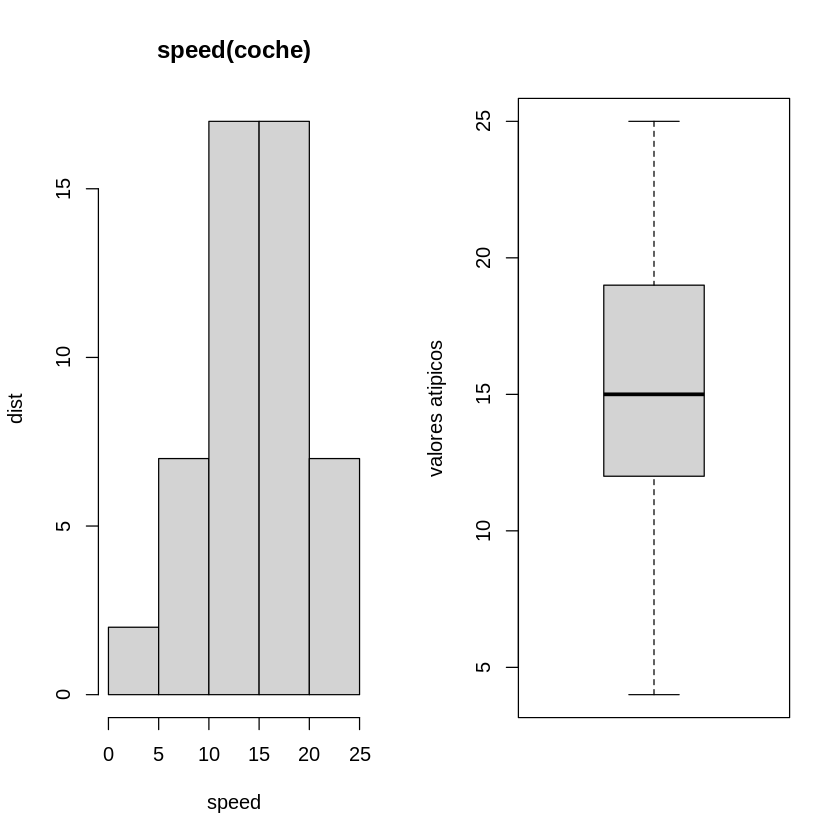

In [8]:
par(mfrow=c(1,2))
hist(coches$speed, xlab = "speed", ylab = "dist", main = "speed(coche)")
boxplot(coches$speed, ylab = "valores atipicos")

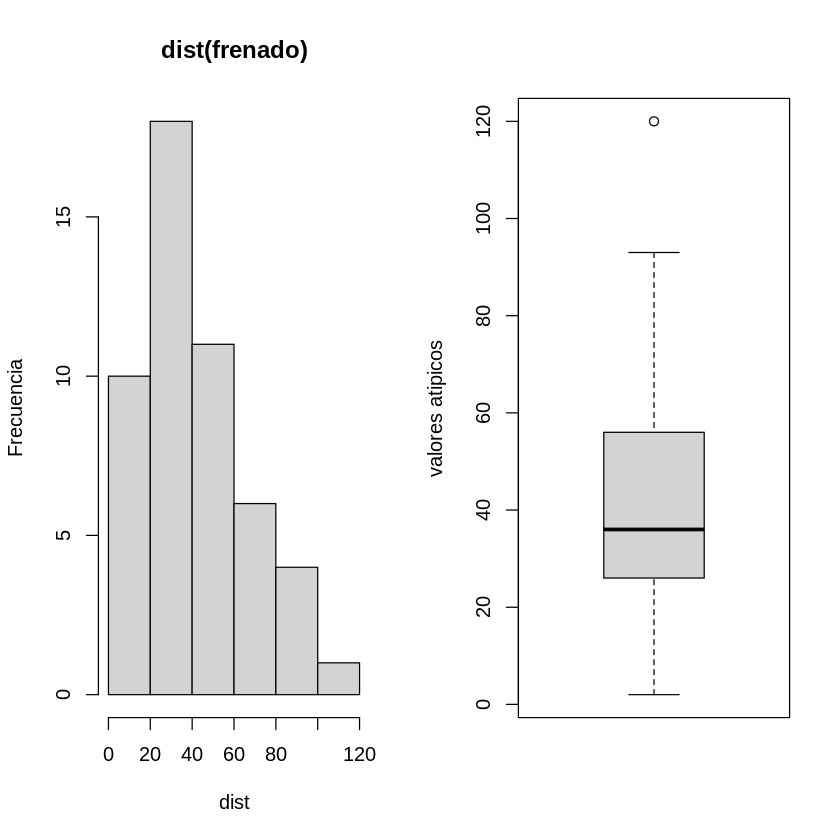

In [13]:
par(mfrow = c(1, 2))
hist(coches$dist, xlab = "dist", ylab = "Frecuencia", main = "dist(frenado)")
boxplot(coches$dist, ylab = "valores atipicos")

In [9]:
cor(coches$speed, coches$dist)

[1] 0.8068949

In [15]:
x <- coches$speed
y <- coches$dist

a1 <- cov(x, y) / var(x)
a0 <- mean(y) - mean(x) * a1

print(a0)
print(a1)

[1] -17.57909
[1] 3.932409


In [16]:
r <- lm(dist ~ speed, data = coches)
summary(r)


Call:
lm(formula = dist ~ speed, data = coches)

Residuals:
    Min      1Q  Median      3Q     Max 
-29.069  -9.525  -2.272   9.215  43.201 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -17.5791     6.7584  -2.601   0.0123 *  
speed         3.9324     0.4155   9.464 1.49e-12 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 15.38 on 48 degrees of freedom
Multiple R-squared:  0.6511,	Adjusted R-squared:  0.6438 
F-statistic: 89.57 on 1 and 48 DF,  p-value: 1.49e-12


Ver como quedo el modelo de regresión

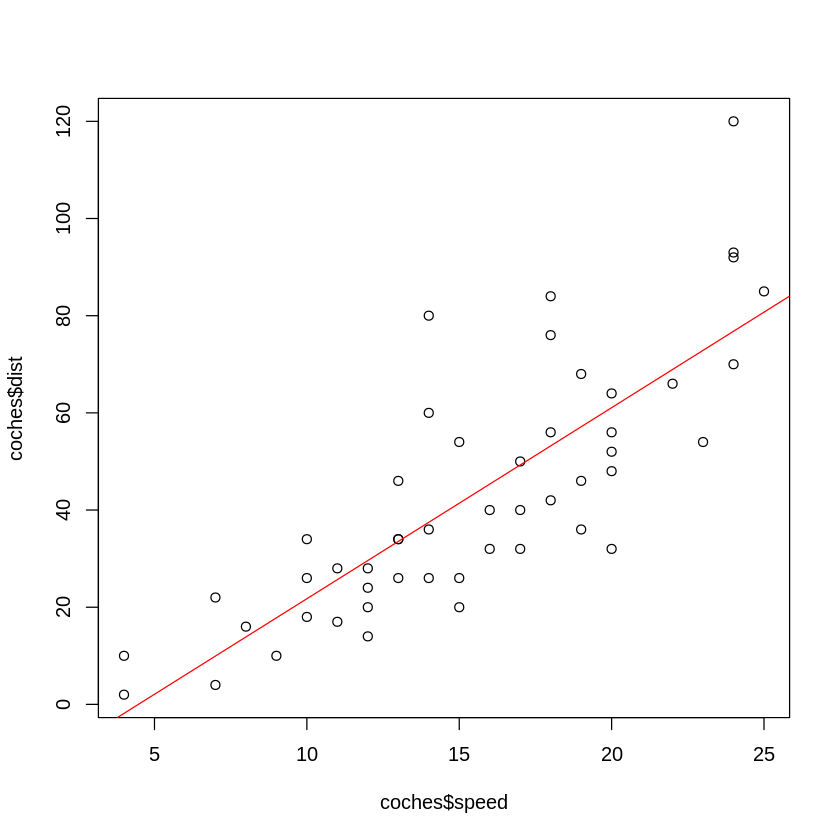

In [18]:
plot(coches$speed, coches$dist)
abline(r, col = "red")

Analisis

La correlación es de .80. Por lo que se nos confirma que hay una relación fuerte entre la velocidad a la que va un coche y la distancia necesaria para que frene.

Pendiente 3.9: Esto nos indica que por cada milla de velocidad mas que tenga el coche, necesitará 3.9 pies para detenerse.

R cuadrado: R cuadrado nos dice que podemos explicar el 65% de la variabilidad total de la distancia requerida en base a la velocidad del modelo. el otro 35% se pueden deber a factores externos que este modelo de regresión lineal simple no contempla.

Intercepto: El intercepto es de -17.5, lo cual es obviamente imposible cuando el coche esta en 0 millas. Pero tiene sentido en el rango de velocidad que se emplearon para estas pruebas.